# Multi-dimensional Visualization of H2 Excited States Results

This notebook provides comprehensive visualizations of the H2 molecule excited state calculations from RBM-2 results.

In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import seaborn as sns
from functools import reduce

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 150
plt.rcParams['font.size'] = 12
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['legend.fontsize'] = 11

# FCI reference energies
E_fci = {
    'E0': -1.01546825,
    'E1': -0.87542794,
    'E2': -0.42938376
}

print("FCI Reference Energies:")
for key, val in E_fci.items():
    print(f"  {key} = {val:.8f} Ha")

FCI Reference Energies:
  E0 = -1.01546825 Ha
  E1 = -0.87542794 Ha
  E2 = -0.42938376 Ha


## Load Data from Log Files

In [2]:
# Load ground state data
with open('h2_ground_state.log', 'r') as f:
    data_gs = json.load(f)

# Load first excited state data
with open('h2_excited_state_1.log', 'r') as f:
    data_ex1 = json.load(f)

# Load second excited state data
with open('h2_excited_state_2.log', 'r') as f:
    data_ex2 = json.load(f)

# Extract energy data
iters_gs = np.array(data_gs['Energy']['iters'])
energy_gs = np.array(data_gs['Energy']['Mean']['real'])
energy_gs_err = np.array(data_gs['Energy']['Sigma'])

iters_ex1 = np.array(data_ex1['Energy']['iters'])
energy_ex1 = np.array(data_ex1['Energy']['Mean']['real'])
energy_ex1_err = np.array(data_ex1['Energy']['Sigma'])

iters_ex2 = np.array(data_ex2['Energy']['iters'])
energy_ex2 = np.array(data_ex2['Energy']['Mean']['real'])
energy_ex2_err = np.array(data_ex2['Energy']['Sigma'])

# Final energies
final_energy_gs = energy_gs[-1]
final_energy_ex1 = energy_ex1[-1]
final_energy_ex2 = energy_ex2[-1]

print("Final Energies:")
print(f"  Ground State:     {final_energy_gs:.8f} Ha")
print(f"  1st Excited:      {final_energy_ex1:.8f} Ha")
print(f"  2nd Excited:      {final_energy_ex2:.8f} Ha")

Final Energies:
  Ground State:     -1.01546828 Ha
  1st Excited:      -0.87543047 Ha
  2nd Excited:      -0.87183974 Ha


## 1. Energy Convergence Curves

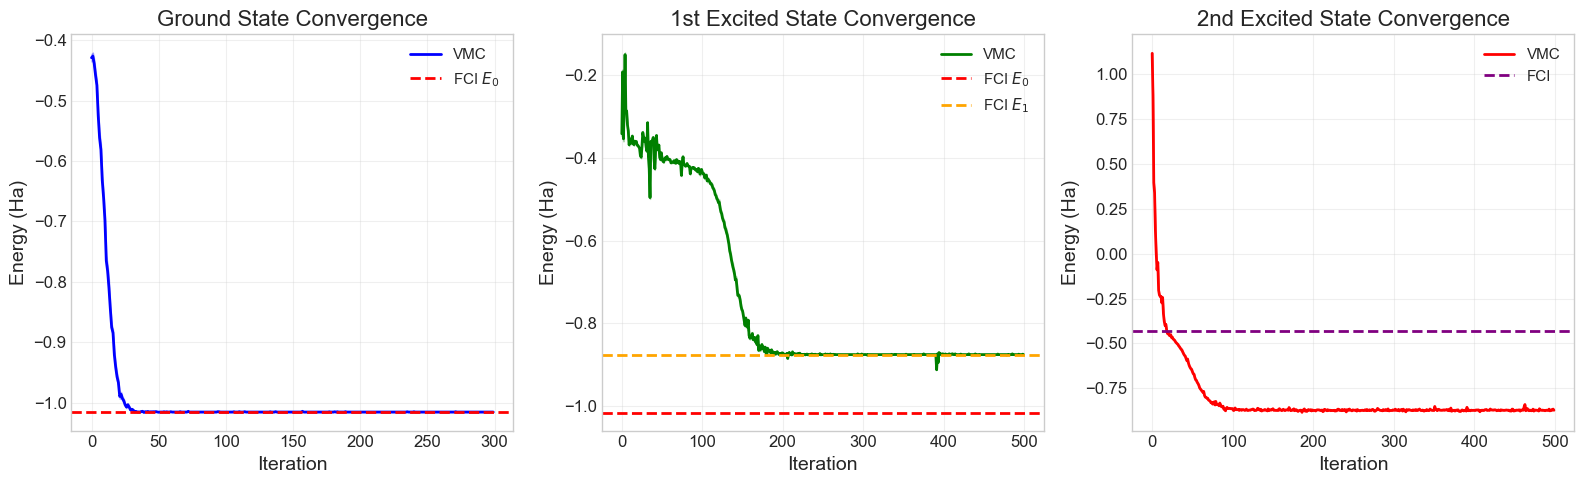

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Ground state
ax = axes[0]
ax.plot(iters_gs, energy_gs, 'b-', linewidth=2, label='VMC')
ax.axhline(y=E_fci['E0'], color='r', linestyle='--', linewidth=2, label='FCI $E_0$' )
ax.fill_between(iters_gs, energy_gs - energy_gs_err, energy_gs + energy_gs_err, 
                alpha=0.3, color='blue')
ax.set_xlabel('Iteration')
ax.set_ylabel('Energy (Ha)')
ax.set_title('Ground State Convergence')
ax.legend()
ax.grid(True, alpha=0.3)

# First excited state
ax = axes[1]
ax.plot(iters_ex1, energy_ex1, 'g-', linewidth=2, label='VMC')
ax.axhline(y=E_fci['E0'], color='r', linestyle='--', linewidth=2, label='FCI $E_0$')
ax.axhline(y=E_fci['E1'], color='orange', linestyle='--', linewidth=2, label='FCI $E_1$' )
ax.fill_between(iters_ex1, energy_ex1 - energy_ex1_err, energy_ex1 + energy_ex1_err, 
                alpha=0.3, color='green')
ax.set_xlabel('Iteration')
ax.set_ylabel('Energy (Ha)')
ax.set_title('1st Excited State Convergence')
ax.legend()
ax.grid(True, alpha=0.3)

# Second excited state
ax = axes[2]
ax.plot(iters_ex2, energy_ex2, 'r-', linewidth=2, label='VMC')
ax.axhline(y=E_fci['E2'], color='purple', linestyle='--', linewidth=2, label='FCI')
ax.fill_between(iters_ex2, energy_ex2 - energy_ex2_err, energy_ex2 + energy_ex2_err, 
                alpha=0.3, color='red')
ax.set_xlabel('Iteration')
ax.set_ylabel('Energy (Ha)')
ax.set_title('2nd Excited State Convergence')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('fig1_convergence_curves.png', bbox_inches='tight')
plt.show()

## 2. Combined Convergence Comparison

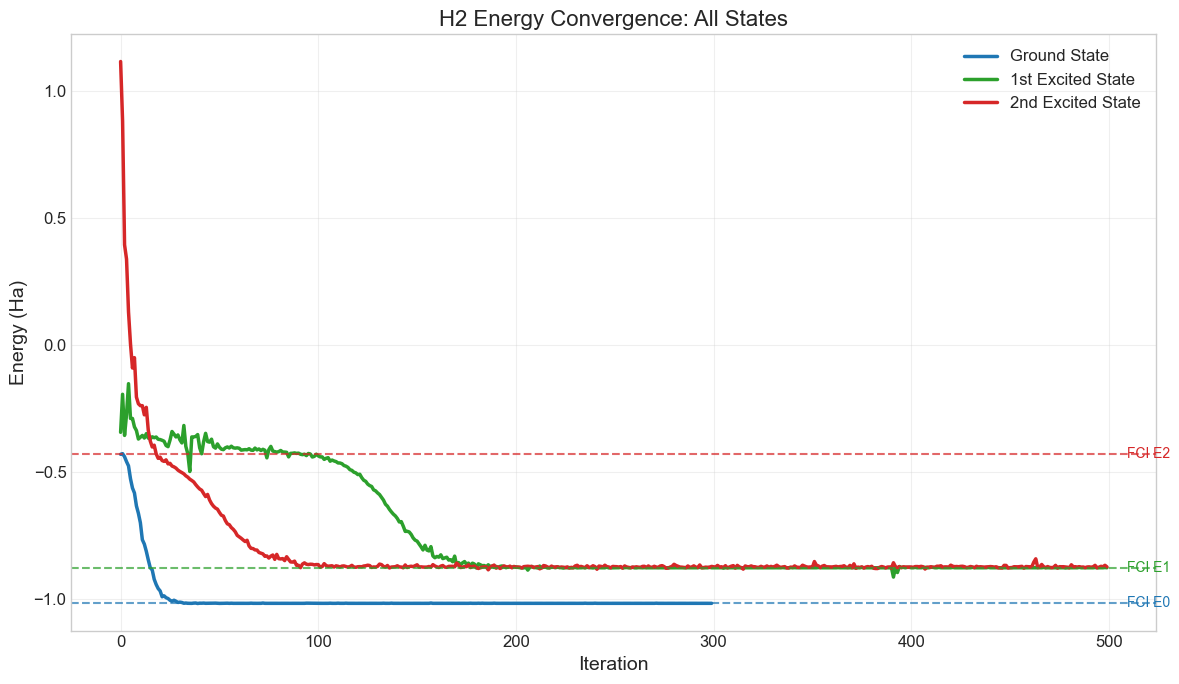

In [14]:
fig, ax = plt.subplots(figsize=(12, 7))

colors = ['#1f77b4', '#2ca02c', '#d62728']

ax.plot(iters_gs, energy_gs, color=colors[0], linewidth=2.5, label='Ground State')
ax.plot(iters_ex1, energy_ex1, color=colors[1], linewidth=2.5, label='1st Excited State')
ax.plot(iters_ex2, energy_ex2, color=colors[2], linewidth=2.5, label='2nd Excited State')

# FCI reference lines
ax.axhline(y=E_fci['E0'], color=colors[0], linestyle='--', alpha=0.7, linewidth=1.5)
ax.axhline(y=E_fci['E1'], color=colors[1], linestyle='--', alpha=0.7, linewidth=1.5)
ax.axhline(y=E_fci['E2'], color=colors[2], linestyle='--', alpha=0.7, linewidth=1.5)

# Add text annotations for FCI
ax.text(max(iters_ex2)*1.02, E_fci['E0'], 'FCI E0', va='center', fontsize=10, color=colors[0])
ax.text(max(iters_ex2)*1.02, E_fci['E1'], 'FCI E1', va='center', fontsize=10, color=colors[1])
ax.text(max(iters_ex2)*1.02, E_fci['E2'], 'FCI E2', va='center', fontsize=10, color=colors[2])

ax.set_xlabel('Iteration', fontsize=14)
ax.set_ylabel('Energy (Ha)', fontsize=14)
ax.set_title('H2 Energy Convergence: All States', fontsize=16)
ax.legend(loc='upper right', fontsize=12)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('fig2_combined_convergence.png', bbox_inches='tight')
plt.show()

## 3. Energy Level Diagram

In [ ]:
fig, ax = plt.subplots(figsize=(12, 8))

# VMC energies
vmc_energies = [final_energy_gs, final_energy_ex1, final_energy_ex2]
fci_energies = [E_fci['E0'], E_fci['E1'], E_fci['E2']]
labels = ['Ground State', '1st Excited', '2nd Excited']
colors = ['#1f77b4', '#2ca02c', '#d62728']

# Plot energy levels
x_vmc = np.arange(0.2, 1.2, 0.1)
x_fci = np.arange(1.5, 2.5, 0.1)

for i, (E_vmc, E_fci_val, label, color) in enumerate(zip(vmc_energies, fci_energies, labels, colors)):
    # VMC level
    ax.hlines(E_vmc, 0.2, 1.0, colors=color, linewidth=4, label=f'VMC {label}')
    ax.text(1.05, E_vmc, f'{E_vmc:.6f} Ha', va='center', fontsize=11, color=color, fontweight='bold')
    
    # FCI level
    ax.hlines(E_fci_val, 1.5, 2.3, colors=color, linewidth=4, linestyle='--', alpha=0.6)
    ax.text(2.35, E_fci_val, f'FCI: {E_fci_val:.6f} Ha', va='center', fontsize=10, color=color, alpha=0.8)

# Add labels
ax.text(0.6, -1.18, 'VMC', ha='center', fontsize=14, fontweight='bold')
ax.text(1.9, -1.18, 'FCI', ha='center', fontsize=14, fontweight='bold')

# Add arrows showing excitation energies
for i in range(1, 3):
    ax.annotate('', xy=(0.6, vmc_energies[i]), xytext=(0.6, vmc_energies[0]),
                arrowprops=dict(arrowstyle='<->', color='gray', lw=1.5))
    exc_energy = vmc_energies[i] - vmc_energies[0]
    mid_y = (vmc_energies[i] + vmc_energies[0]) / 2
    ax.text(0.75, mid_y, f'ΔE = {exc_energy:.4f} Ha\n({exc_energy*27.2114:.2f} eV)', 
            fontsize=9, va='center')

ax.set_xlim(-0.1, 3.5)
ax.set_ylim(-1.2, -0.3)
ax.set_ylabel('Energy (Ha)', fontsize=14)
ax.set_title('H2 Molecular Energy Levels', fontsize=16)
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, axis='y', alpha=0.3)
ax.set_xticks([])

plt.tight_layout()
plt.savefig('fig3_energy_levels.png', bbox_inches='tight')
plt.show()

## 4. Error Analysis

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Calculate errors
error_gs = np.abs(energy_gs - E_fci['E0'])
error_ex1 = np.abs(energy_ex1 - E_fci['E1'])
error_ex2 = np.abs(energy_ex2 - E_fci['E2'])

# Plot 1: Absolute error convergence
ax = axes[0, 0]
ax.semilogy(iters_gs, error_gs, 'b-', linewidth=2, label='Ground State')
ax.semilogy(iters_ex1, error_ex1, 'g-', linewidth=2, label='1st Excited')
ax.semilogy(iters_ex2, error_ex2, 'r-', linewidth=2, label='2nd Excited')
ax.set_xlabel('Iteration')
ax.set_ylabel('|E - E_FCI| (Ha)')
ax.set_title('Absolute Error Convergence')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 2: Final error bar chart
ax = axes[0, 1]
final_errors = [error_gs[-1], error_ex1[-1], error_ex2[-1]]
bars = ax.bar(['Ground\nState', '1st\nExcited', '2nd\nExcited'], final_errors, 
              color=['#1f77b4', '#2ca02c', '#d62728'], edgecolor='black', linewidth=1.5)
ax.set_ylabel('Error (Ha)')
ax.set_title('Final Energy Error vs FCI')
ax.set_yscale('log')
ax.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar, err in zip(bars, final_errors):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.5, 
            f'{err:.2e}', ha='center', va='bottom', fontsize=10)

# Plot 3: Error distribution heatmap
ax = axes[1, 0]
# Create error matrix for heatmap
n_bins = 20
error_data = []
for err_arr, label in [(error_gs, 'GS'), (error_ex1, 'Ex1'), (error_ex2, 'Ex2')]:
    binned = np.array_split(err_arr, n_bins)
    mean_err = [np.mean(b) for b in binned]
    error_data.append(mean_err)

error_matrix = np.array(error_data)
sns.heatmap(error_matrix, ax=ax, cmap='YlOrRd', 
            xticklabels=[f'{i*5}-{(i+1)*5}%' for i in range(n_bins)],
            yticklabels=['Ground State', '1st Excited', '2nd Excited'],
            cbar_kws={'label': 'Error (Ha)'})
ax.set_title('Error Evolution Heatmap')
ax.set_xlabel('Training Progress')

# Plot 4: Relative error percentage
ax = axes[1, 1]
rel_error_gs = error_gs / np.abs(E_fci['E0']) * 100
rel_error_ex1 = error_ex1 / np.abs(E_fci['E1']) * 100
rel_error_ex2 = error_ex2 / np.abs(E_fci['E2']) * 100

ax.semilogy(iters_gs, rel_error_gs, 'b-', linewidth=2, label='Ground State')
ax.semilogy(iters_ex1, rel_error_ex1, 'g-', linewidth=2, label='1st Excited')
ax.semilogy(iters_ex2, rel_error_ex2, 'r-', linewidth=2, label='2nd Excited')
ax.set_xlabel('Iteration')
ax.set_ylabel('Relative Error (%)')
ax.set_title('Relative Error Convergence')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('fig4_error_analysis.png', bbox_inches='tight')
plt.show()

## 5. Excitation Energy Analysis

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Calculate excitation energies
exc_energy_1_vmc = energy_ex1 - energy_gs[-1]  # Use final ground state
exc_energy_2_vmc = energy_ex2 - energy_gs[-1]

exc_energy_1_fci = E_fci['E1'] - E_fci['E0']
exc_energy_2_fci = E_fci['E2'] - E_fci['E0']

# Plot 1: Excitation energy convergence
ax = axes[0, 0]
ax.plot(iters_ex1, exc_energy_1_vmc, 'g-', linewidth=2, label='1st Excitation (VMC)')
ax.plot(iters_ex2, exc_energy_2_vmc, 'r-', linewidth=2, label='2nd Excitation (VMC)')
ax.axhline(y=exc_energy_1_fci, color='green', linestyle='--', alpha=0.7, label=f'1st FCI: {exc_energy_1_fci:.4f} Ha')
ax.axhline(y=exc_energy_2_fci, color='red', linestyle='--', alpha=0.7, label=f'2nd FCI: {exc_energy_2_fci:.4f} Ha')
ax.set_xlabel('Iteration')
ax.set_ylabel('Excitation Energy (Ha)')
ax.set_title('Excitation Energy Convergence')
ax.legend(loc='upper right', fontsize=9)
ax.grid(True, alpha=0.3)

# Plot 2: Excitation energy in eV
ax = axes[0, 1]
Ha_to_eV = 27.2114
ax.plot(iters_ex1, exc_energy_1_vmc * Ha_to_eV, 'g-', linewidth=2, label='1st Excitation')
ax.plot(iters_ex2, exc_energy_2_vmc * Ha_to_eV, 'r-', linewidth=2, label='2nd Excitation')
ax.axhline(y=exc_energy_1_fci * Ha_to_eV, color='green', linestyle='--', alpha=0.7)
ax.axhline(y=exc_energy_2_fci * Ha_to_eV, color='red', linestyle='--', alpha=0.7)
ax.set_xlabel('Iteration')
ax.set_ylabel('Excitation Energy (eV)')
ax.set_title('Excitation Energy in eV')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 3: Excitation energy error
ax = axes[1, 0]
exc_error_1 = np.abs(exc_energy_1_vmc - exc_energy_1_fci)
exc_error_2 = np.abs(exc_energy_2_vmc - exc_energy_2_fci)

ax.semilogy(iters_ex1, exc_error_1, 'g-', linewidth=2, label='1st Excitation Error')
ax.semilogy(iters_ex2, exc_error_2, 'r-', linewidth=2, label='2nd Excitation Error')
ax.set_xlabel('Iteration')
ax.set_ylabel('|ΔE - ΔE_FCI| (Ha)')
ax.set_title('Excitation Energy Error')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 4: Final excitation energy comparison
ax = axes[1, 1]
x = np.arange(2)
width = 0.35

vmc_exc = [exc_energy_1_vmc[-1], exc_energy_2_vmc[-1]]
fci_exc = [exc_energy_1_fci, exc_energy_2_fci]

bars1 = ax.bar(x - width/2, vmc_exc, width, label='VMC', color=['#2ca02c', '#d62728'], 
               edgecolor='black', linewidth=1.5)
bars2 = ax.bar(x + width/2, fci_exc, width, label='FCI', color=['#2ca02c', '#d62728'], 
               edgecolor='black', linewidth=1.5, alpha=0.5, hatch='//')

ax.set_ylabel('Excitation Energy (Ha)')
ax.set_title('Final Excitation Energies Comparison')
ax.set_xticks(x)
ax.set_xticklabels(['1st Excitation', '2nd Excitation'])
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# Add value labels
for bar, val in zip(bars1, vmc_exc):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
            f'{val:.4f}', ha='center', va='bottom', fontsize=10)
for bar, val in zip(bars2, fci_exc):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
            f'{val:.4f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('fig5_excitation_energy.png', bbox_inches='tight')
plt.show()

## 6. Statistical Analysis

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Energy variance (Sigma)
ax = axes[0, 0]
ax.semilogy(iters_gs, energy_gs_err, 'b-', linewidth=2, label='Ground State')
ax.semilogy(iters_ex1, energy_ex1_err, 'g-', linewidth=2, label='1st Excited')
ax.semilogy(iters_ex2, energy_ex2_err, 'r-', linewidth=2, label='2nd Excited')
ax.set_xlabel('Iteration')
ax.set_ylabel('Energy Variance (Ha)')
ax.set_title('Energy Variance Convergence')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 2: Acceptance rate
ax = axes[0, 1]
accept_gs = np.array(data_gs['acceptance']['value'])
accept_ex1 = np.array(data_ex1['acceptance']['value'])
accept_ex2 = np.array(data_ex2['acceptance']['value'])

ax.plot(iters_gs, accept_gs, 'b-', linewidth=2, label='Ground State', alpha=0.7)
ax.plot(iters_ex1, accept_ex1, 'g-', linewidth=2, label='1st Excited', alpha=0.7)
ax.plot(iters_ex2, accept_ex2, 'r-', linewidth=2, label='2nd Excited', alpha=0.7)
ax.set_xlabel('Iteration')
ax.set_ylabel('Acceptance Rate')
ax.set_title('MCMC Acceptance Rate')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 1)

# Plot 3: Energy distribution (violin plot)
ax = axes[1, 0]
# Use last 50 iterations for distribution
n_last = 50
data_for_violin = [energy_gs[-n_last:], energy_ex1[-n_last:], energy_ex2[-n_last:]]
positions = [1, 2, 3]
colors = ['#1f77b4', '#2ca02c', '#d62728']

parts = ax.violinplot(data_for_violin, positions=positions, showmeans=True, showmedians=True)
for i, pc in enumerate(parts['bodies']):
    pc.set_facecolor(colors[i])
    pc.set_alpha(0.7)

# Add FCI reference points
ax.scatter([1, 2, 3], [E_fci['E0'], E_fci['E1'], E_fci['E2']], 
           color='red', marker='*', s=200, zorder=5, label='FCI')

ax.set_xticks([1, 2, 3])
ax.set_xticklabels(['Ground\nState', '1st\nExcited', '2nd\nExcited'])
ax.set_ylabel('Energy (Ha)')
ax.set_title('Energy Distribution (Last 50 Iterations)')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# Plot 4: Summary statistics table
ax = axes[1, 1]
ax.axis('off')

# Create summary data
summary_data = [
    ['State', 'VMC Energy (Ha)', 'FCI Energy (Ha)', 'Error (Ha)', 'Error (%)'],
    ['Ground', f'{final_energy_gs:.8f}', f'{E_fci["E0"]:.8f}', 
     f'{error_gs[-1]:.2e}', f'{rel_error_gs[-1]:.4f}'],
    ['1st Excited', f'{final_energy_ex1:.8f}', f'{E_fci["E1"]:.8f}', 
     f'{error_ex1[-1]:.2e}', f'{rel_error_ex1[-1]:.4f}'],
    ['2nd Excited', f'{final_energy_ex2:.8f}', f'{E_fci["E2"]:.8f}', 
     f'{error_ex2[-1]:.2e}', f'{rel_error_ex2[-1]:.4f}'],
]

table = ax.table(cellText=summary_data[1:], colLabels=summary_data[0],
                 loc='center', cellLoc='center',
                 colColours=['#f0f0f0']*5)
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 1.8)

# Color the first column
for i in range(1, 4):
    table[(i, 0)].set_facecolor(colors[i-1])
    table[(i, 0)].set_text_props(color='white', fontweight='bold')

ax.set_title('Summary Statistics', fontsize=14, pad=20)

plt.tight_layout()
plt.savefig('fig6_statistics.png', bbox_inches='tight')
plt.show()

## 7. Comprehensive Dashboard

In [ ]:
# Create a comprehensive dashboard
fig = plt.figure(figsize=(20, 16))
gs = GridSpec(3, 3, figure=fig, hspace=0.3, wspace=0.3)

# Panel 1: Energy convergence (top-left, spans 2 columns)
ax1 = fig.add_subplot(gs[0, :2])
ax1.plot(iters_gs, energy_gs, 'b-', linewidth=2, label='Ground State')
ax1.plot(iters_ex1, energy_ex1, 'g-', linewidth=2, label='1st Excited')
ax1.plot(iters_ex2, energy_ex2, 'r-', linewidth=2, label='2nd Excited')
ax1.axhline(y=E_fci['E0'], color='blue', linestyle='--', alpha=0.5)
ax1.axhline(y=E_fci['E1'], color='green', linestyle='--', alpha=0.5)
ax1.axhline(y=E_fci['E2'], color='red', linestyle='--', alpha=0.5)
ax1.set_xlabel('Iteration')
ax1.set_ylabel('Energy (Ha)')
ax1.set_title('Energy Convergence', fontsize=14)
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)

# Panel 2: Energy levels (top-right)
ax2 = fig.add_subplot(gs[0, 2])
for i, (E_vmc, E_fci_val, color, label) in enumerate(zip(
    [final_energy_gs, final_energy_ex1, final_energy_ex2],
    [E_fci['E0'], E_fci['E1'], E_fci['E2']],
    ['#1f77b4', '#2ca02c', '#d62728'],
    ['E0', 'E1', 'E2'])):
    ax2.hlines(E_vmc, 0, 1, colors=color, linewidth=4)
    ax2.hlines(E_fci_val, 1.2, 2.2, colors=color, linewidth=4, linestyle='--', alpha=0.6)
ax2.set_xlim(-0.2, 2.5)
ax2.set_ylabel('Energy (Ha)')
ax2.set_title('Energy Levels', fontsize=14)
ax2.set_xticks([0.5, 1.7])
ax2.set_xticklabels(['VMC', 'FCI'])
ax2.grid(True, alpha=0.3, axis='y')

# Panel 3: Error convergence (middle-left)
ax3 = fig.add_subplot(gs[1, 0])
ax3.semilogy(iters_gs, error_gs, 'b-', linewidth=2, label='Ground')
ax3.semilogy(iters_ex1, error_ex1, 'g-', linewidth=2, label='1st Ex')
ax3.semilogy(iters_ex2, error_ex2, 'r-', linewidth=2, label='2nd Ex')
ax3.set_xlabel('Iteration')
ax3.set_ylabel('|E - E_FCI| (Ha)')
ax3.set_title('Error Convergence', fontsize=14)
ax3.legend(fontsize=9)
ax3.grid(True, alpha=0.3)

# Panel 4: Excitation energies (middle-center)
ax4 = fig.add_subplot(gs[1, 1])
ax4.plot(iters_ex1, exc_energy_1_vmc * Ha_to_eV, 'g-', linewidth=2, label='1st')
ax4.plot(iters_ex2, exc_energy_2_vmc * Ha_to_eV, 'r-', linewidth=2, label='2nd')
ax4.axhline(y=exc_energy_1_fci * Ha_to_eV, color='green', linestyle='--', alpha=0.7)
ax4.axhline(y=exc_energy_2_fci * Ha_to_eV, color='red', linestyle='--', alpha=0.7)
ax4.set_xlabel('Iteration')
ax4.set_ylabel('Excitation Energy (eV)')
ax4.set_title('Excitation Energies', fontsize=14)
ax4.legend(fontsize=9)
ax4.grid(True, alpha=0.3)

# Panel 5: Variance (middle-right)
ax5 = fig.add_subplot(gs[1, 2])
ax5.semilogy(iters_gs, energy_gs_err, 'b-', linewidth=2, label='Ground')
ax5.semilogy(iters_ex1, energy_ex1_err, 'g-', linewidth=2, label='1st Ex')
ax5.semilogy(iters_ex2, energy_ex2_err, 'r-', linewidth=2, label='2nd Ex')
ax5.set_xlabel('Iteration')
ax5.set_ylabel('Variance (Ha)')
ax5.set_title('Energy Variance', fontsize=14)
ax5.legend(fontsize=9)
ax5.grid(True, alpha=0.3)

# Panel 6: Bar chart comparison (bottom-left)
ax6 = fig.add_subplot(gs[2, 0])
x = np.arange(3)
width = 0.35
bars1 = ax6.bar(x - width/2, [final_energy_gs, final_energy_ex1, final_energy_ex2], 
                width, label='VMC', color=['#1f77b4', '#2ca02c', '#d62728'], 
                edgecolor='black')
bars2 = ax6.bar(x + width/2, [E_fci['E0'], E_fci['E1'], E_fci['E2']], 
                width, label='FCI', color=['#1f77b4', '#2ca02c', '#d62728'], 
                edgecolor='black', alpha=0.5, hatch='//')
ax6.set_ylabel('Energy (Ha)')
ax6.set_title('Energy Comparison', fontsize=14)
ax6.set_xticks(x)
ax6.set_xticklabels(['E0', 'E1', 'E2'])
ax6.legend(fontsize=9)
ax6.grid(True, alpha=0.3, axis='y')

# Panel 7: Acceptance rate (bottom-center)
ax7 = fig.add_subplot(gs[2, 1])
ax7.plot(iters_gs, accept_gs, 'b-', linewidth=1.5, alpha=0.7, label='Ground')
ax7.plot(iters_ex1, accept_ex1, 'g-', linewidth=1.5, alpha=0.7, label='1st Ex')
ax7.plot(iters_ex2, accept_ex2, 'r-', linewidth=1.5, alpha=0.7, label='2nd Ex')
ax7.set_xlabel('Iteration')
ax7.set_ylabel('Acceptance Rate')
ax7.set_title('MCMC Acceptance', fontsize=14)
ax7.legend(fontsize=9)
ax7.grid(True, alpha=0.3)
ax7.set_ylim(0, 1)

# Panel 8: Summary table (bottom-right)
ax8 = fig.add_subplot(gs[2, 2])
ax8.axis('off')

summary_text = f"""Summary Results
{'='*35}
Ground State:
  VMC: {final_energy_gs:.8f} Ha
  FCI: {E_fci['E0']:.8f} Ha
  Error: {error_gs[-1]:.2e} Ha

1st Excited State:
  VMC: {final_energy_ex1:.8f} Ha
  FCI: {E_fci['E1']:.8f} Ha
  Error: {error_ex1[-1]:.2e} Ha

2nd Excited State:
  VMC: {final_energy_ex2:.8f} Ha
  FCI: {E_fci['E2']:.8f} Ha
  Error: {error_ex2[-1]:.2e} Ha

Excitation Energies:
  1st: {exc_energy_1_vmc[-1]*Ha_to_eV:.4f} eV (FCI: {exc_energy_1_fci*Ha_to_eV:.4f} eV)
  2nd: {exc_energy_2_vmc[-1]*Ha_to_eV:.4f} eV (FCI: {exc_energy_2_fci*Ha_to_eV:.4f} eV)
"""

ax8.text(0.1, 0.95, summary_text, transform=ax8.transAxes, fontsize=10,
         verticalalignment='top', fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

fig.suptitle('H2 Molecule Excited States - Comprehensive Dashboard', fontsize=18, y=0.98)

plt.savefig('fig7_dashboard.png', bbox_inches='tight')
plt.show()

## 8. Convergence Rate Analysis

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Calculate convergence rate (derivative of energy)
def calc_convergence_rate(energy, iters):
    rate = np.abs(np.diff(energy) / np.diff(iters))
    return rate, iters[1:]

rate_gs, iters_rate_gs = calc_convergence_rate(energy_gs, iters_gs)
rate_ex1, iters_rate_ex1 = calc_convergence_rate(energy_ex1, iters_ex1)
rate_ex2, iters_rate_ex2 = calc_convergence_rate(energy_ex2, iters_ex2)

# Plot 1: Convergence rate
ax = axes[0]
ax.semilogy(iters_rate_gs, rate_gs, 'b-', linewidth=2, label='Ground State', alpha=0.7)
ax.semilogy(iters_rate_ex1, rate_ex1, 'g-', linewidth=2, label='1st Excited', alpha=0.7)
ax.semilogy(iters_rate_ex2, rate_ex2, 'r-', linewidth=2, label='2nd Excited', alpha=0.7)
ax.set_xlabel('Iteration')
ax.set_ylabel('|dE/dt| (Ha/iter)')
ax.set_title('Energy Change Rate')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 2: Cumulative energy change
ax = axes[1]
cumsum_gs = np.cumsum(np.abs(np.diff(energy_gs)))
cumsum_ex1 = np.cumsum(np.abs(np.diff(energy_ex1)))
cumsum_ex2 = np.cumsum(np.abs(np.diff(energy_ex2)))

ax.plot(iters_gs[1:], cumsum_gs, 'b-', linewidth=2, label='Ground State')
ax.plot(iters_ex1[1:], cumsum_ex1, 'g-', linewidth=2, label='1st Excited')
ax.plot(iters_ex2[1:], cumsum_ex2, 'r-', linewidth=2, label='2nd Excited')
ax.set_xlabel('Iteration')
ax.set_ylabel('Cumulative |ΔE| (Ha)')
ax.set_title('Cumulative Energy Change')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('fig8_convergence_rate.png', bbox_inches='tight')
plt.show()

## 9. Radar Chart Comparison

In [ ]:
# Create radar chart for multi-metric comparison
fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(projection='polar'))

# Define metrics (normalized to 0-1 scale)
categories = ['Accuracy\n(1-Error)', 'Convergence\nSpeed', 'Stability\n(1-Var)', 
              'Acceptance\nRate', 'Excitation\nQuality']
N = len(categories)

# Calculate metrics
def calc_metrics(energy, error, variance, acceptance, exc_error=None):
    accuracy = 1 - min(error[-1] / 0.1, 1)  # Normalize error
    conv_speed = 1 - len(energy) / 1000  # Normalize iterations
    stability = 1 - min(variance[-1] / 0.01, 1)  # Normalize variance
    accept = np.mean(acceptance[-50:])  # Average final acceptance
    exc_qual = 1 - min(exc_error / 0.5, 1) if exc_error is not None else 0.5
    return [accuracy, conv_speed, stability, accept, exc_qual]

metrics_gs = calc_metrics(energy_gs, error_gs, energy_gs_err, accept_gs, 0)
metrics_ex1 = calc_metrics(energy_ex1, error_ex1, energy_ex1_err, accept_ex1, exc_error_1[-1])
metrics_ex2 = calc_metrics(energy_ex2, error_ex2, energy_ex2_err, accept_ex2, exc_error_2[-1])

# Number of variables
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

# Add data
metrics_gs += metrics_gs[:1]
metrics_ex1 += metrics_ex1[:1]
metrics_ex2 += metrics_ex2[:1]

# Plot
ax.plot(angles, metrics_gs, 'b-', linewidth=2, label='Ground State')
ax.fill(angles, metrics_gs, 'b', alpha=0.1)

ax.plot(angles, metrics_ex1, 'g-', linewidth=2, label='1st Excited')
ax.fill(angles, metrics_ex1, 'g', alpha=0.1)

ax.plot(angles, metrics_ex2, 'r-', linewidth=2, label='2nd Excited')
ax.fill(angles, metrics_ex2, 'r', alpha=0.1)

# Set labels
ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=11)
ax.set_ylim(0, 1)
ax.set_title('Multi-Metric Performance Comparison', fontsize=14, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))

plt.tight_layout()
plt.savefig('fig9_radar_chart.png', bbox_inches='tight')
plt.show()

## 10. 3D Surface Plot

In [ ]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(14, 6))

# 3D surface of energy landscape
ax1 = fig.add_subplot(121, projection='3d')

# Create mesh for iteration and state
max_iter = min(len(iters_gs), len(iters_ex1), len(iters_ex2))
iters_3d = np.arange(max_iter)
states = np.array([0, 1, 2])  # 0: GS, 1: Ex1, 2: Ex2

ITERS, STATES = np.meshgrid(iters_3d, states)
ENERGIES = np.array([
    energy_gs[:max_iter],
    energy_ex1[:max_iter],
    energy_ex2[:max_iter]
])

surf = ax1.plot_surface(ITERS, STATES, ENERGIES, cmap='viridis', alpha=0.8)
ax1.set_xlabel('Iteration')
ax1.set_ylabel('State (0=GS, 1=Ex1, 2=Ex2)')
ax1.set_zlabel('Energy (Ha)')
ax1.set_title('3D Energy Landscape')
fig.colorbar(surf, ax=ax1, shrink=0.5, aspect=10, label='Energy (Ha)')

# 3D error surface
ax2 = fig.add_subplot(122, projection='3d')

ERRORS = np.array([
    error_gs[:max_iter],
    error_ex1[:max_iter],
    error_ex2[:max_iter]
])

surf2 = ax2.plot_surface(ITERS, STATES, np.log10(ERRORS + 1e-15), cmap='hot', alpha=0.8)
ax2.set_xlabel('Iteration')
ax2.set_ylabel('State (0=GS, 1=Ex1, 2=Ex2)')
ax2.set_zlabel('log₁₀(Error) (Ha)')
ax2.set_title('3D Error Surface')
fig.colorbar(surf2, ax=ax2, shrink=0.5, aspect=10, label='log₁₀(Error)')

plt.tight_layout()
plt.savefig('fig10_3d_surface.png', bbox_inches='tight')
plt.show()

## Summary

This notebook provides comprehensive multi-dimensional visualizations of the H2 molecule excited state calculations:

1. **Energy Convergence**: Individual and combined convergence curves
2. **Energy Levels**: Visual comparison of VMC and FCI energy levels
3. **Error Analysis**: Absolute and relative errors, error evolution
4. **Excitation Energies**: Convergence and comparison with FCI
5. **Statistical Analysis**: Variance, acceptance rate, distributions
6. **Dashboard**: Comprehensive overview in a single figure
7. **Convergence Rate**: Energy change rate analysis
8. **Radar Chart**: Multi-metric performance comparison
9. **3D Visualization**: Energy and error surfaces